In [1]:
import pandas as pd
import matplotlib.pyplot as plt



In [2]:
df = pd.read_csv("prestamos_automovil.csv")
df.head()


,ID,Edad,Ingresos,Monto_Inicial,Scoring_Crediticio,Meses_Empleo,Num_Creditos,Ratio_Interes,Duracion,Ratio_Deuda_Ingresos,Estudios,Tipo_Jornada_Laboral,Estado_Civil,Posesion_Hipoteca,Personas_Cargo,Proposito,Fiador,Impago,Prima
0,O77MPJ,26,19153.0,6973,706,9.0,1,19.05,36.0,0.10,Grado Universitario,Jornada completa,Soltero,0.0,1.0,Automóvil,1.0,1,130.83
1,IYOL1S,29,39531.0,40000,826,0.0,1,9.74,24.0,0.19,Doctorado,Jornada completa,Casado,0.0,0.0,Automóvil,1.0,0,208.64
2,FRMZVN,29,40348.0,16448,740,9.0,1,14.73,24.0,0.10,Máster,Jornada completa,Soltero,0.0,1.0,Automóvil,0.0,1,101.94
3,YKHXVY,38,41732.0,42040,661,173.0,2,13.24,48.0,0.18,Grado Universitario,Tiempo parcial,Casado,1.0,0.0,Automóvil,1.0,1,800.00
4,NHDJTK,35,35085.0,16406,759,181.0,1,9.74,36.0,0.13,Escolar,Jornada completa,Casado,0.0,1.0,Automóvil,0.0,0,94.42


In [3]:
print("Filas:", len(df))

Filas: 76924


## Datos Necesarios

In [4]:
PAGOS_AÑO = 12   # cuotas mensuales

df["Num_Cuotas"] = df["Duracion"]
df["Tipo_Interes_Anual"] = df["Ratio_Interes"] / 100
df["Tipo_Interes_Mensual"] = df["Tipo_Interes_Anual"] / PAGOS_AÑO

P = df["Monto_Inicial"]
n = df["Num_Cuotas"]
i = df["Tipo_Interes_Mensual"]

df[["Monto_Inicial", "Num_Cuotas", "Tipo_Interes_Anual", "Tipo_Interes_Mensual"]].head()

,Monto_Inicial,Num_Cuotas,Tipo_Interes_Anual,Tipo_Interes_Mensual
0,6973,36.0,0.1905,0.015875
1,40000,24.0,0.0974,0.008117
2,16448,24.0,0.1473,0.012275
3,42040,48.0,0.1324,0.011033
4,16406,36.0,0.0974,0.008117


## Amortización Alemana

In [5]:
df["ALEMANA_Devolucion"] = P / n
df["ALEMANA_Interes_Cuota1"] = P * i
df["ALEMANA_Cuota_Primera"] = df["ALEMANA_Devolucion"] + df["ALEMANA_Interes_Cuota1"]
df["ALEMANA_Cuota_Ultima"] = df["ALEMANA_Devolucion"] * (1 + i)
df["ALEMANA_Intereses_Totales"] = P * i * (n + 1) / 2
df["ALEMANA_Coste_Total"] = P + df["ALEMANA_Intereses_Totales"]

df.filter(like="ALEMANA").head().round(2)

,ALEMANA_Devolucion,ALEMANA_Interes_Cuota1,ALEMANA_Cuota_Primera,ALEMANA_Cuota_Ultima,ALEMANA_Intereses_Totales,ALEMANA_Coste_Total
0,193.69,110.70,304.39,196.77,2047.88,9020.88
1,1666.67,324.67,1991.33,1680.19,4058.33,44058.33
2,685.33,201.90,887.23,693.75,2523.74,18971.74
3,875.83,463.84,1339.67,885.50,11364.11,53404.11
4,455.72,133.16,588.88,459.42,2463.50,18869.50


## Amortización Francesa

In [6]:
df["FRANCESA_Cuota"] = P * i / (1 - (1 + i) ** (-n))
df["FRANCESA_Interes_Cuota1"] = P * i
df["FRANCESA_Devolucion_Cuota1"] = df["FRANCESA_Cuota"] - df["FRANCESA_Interes_Cuota1"]
df["FRANCESA_Coste_Total"] = df["FRANCESA_Cuota"] * n
df["FRANCESA_Intereses_Totales"] = df["FRANCESA_Coste_Total"] - P

df.filter(like="FRANCESA").head().round(2)

,FRANCESA_Cuota,FRANCESA_Interes_Cuota1,FRANCESA_Devolucion_Cuota1,FRANCESA_Coste_Total,FRANCESA_Intereses_Totales
0,255.78,110.70,145.08,9208.03,2235.03
1,1841.00,324.67,1516.33,44184.02,4184.02
2,795.40,201.90,593.50,19089.60,2641.60
3,1132.84,463.84,669.00,54376.42,12336.42
4,527.38,133.16,394.21,18985.50,2579.50


## Comparacion

In [7]:
comparacion= pd.DataFrame({ "Alemana": [df["ALEMANA_Cuota_Primera"].mean(), df["ALEMANA_Cuota_Ultima"].mean(), df["ALEMANA_Intereses_Totales"].mean(), df["ALEMANA_Coste_Total"].mean()],
                           "Francesa": [df["FRANCESA_Cuota"].mean(), df["FRANCESA_Cuota"].mean(),df["FRANCESA_Intereses_Totales"].mean(), df["FRANCESA_Coste_Total"].mean()],
                           }, index=["Primera cuota", "Última cuota", "Intereses totales", "Coste total"])



In [8]:
comparacion["Diferencia (FRANCESA - ALEMANA)"] = comparacion["Francesa"] - comparacion["Alemana"]
comparacion.round(2)

,Alemana,Francesa,Diferencia (FRANCESA - ALEMANA)
Primera cuota,1870.25,1690.46,-179.79
Última cuota,1486.18,1690.46,204.28
Intereses totales,7612.82,8135.84,523.02
Coste total,52343.00,52866.02,523.02


In [9]:
df["Duracion"].value_counts()

Duracion
36.0    26863
48.0    15424
24.0    15365
60.0    11641
12.0     7631
Name: count, dtype: int64

In [10]:
duracion = df.groupby("Duracion")[["ALEMANA_Intereses_Totales", "FRANCESA_Intereses_Totales"]].mean()
duracion

,ALEMANA_Intereses_Totales,FRANCESA_Intereses_Totales
Duracion,,
12.0,2573.146242,2620.005583
24.0,4913.225146,5100.514518
36.0,7357.814817,7783.828303
48.0,9725.133163,10478.750917
60.0,12269.341209,13465.973016


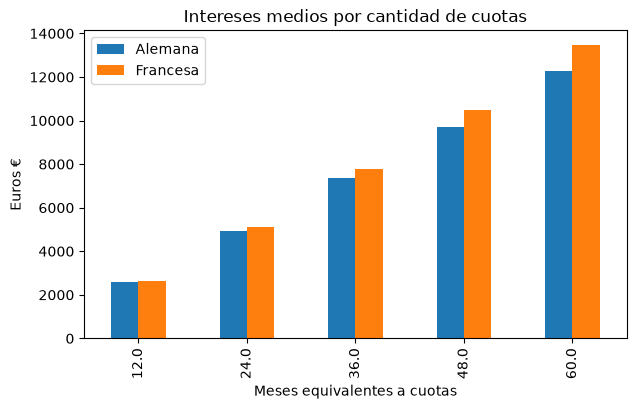

In [11]:
duracion.plot(kind="bar", figsize=(7, 4))
plt.title("Intereses medios por cantidad de cuotas")
plt.xlabel("Meses equivalentes a cuotas")
plt.ylabel("Euros €")
plt.legend(["Alemana", "Francesa"])
plt.show()